In [12]:
import matplotlib.pyplot as plt
import numpy as np
import json
import re
from pathlib import Path


# Helper Functions for analysis

def load_all_AFM(root_dir, sample_name="Unspecified"):
    afm_data = []
    root_dir = Path(root_dir)

    fname_pattern = re.compile(
        r"TLW-(?P<TLW>[^-]+)-BLW-(?P<BLW>[^-]+)-S-(?P<S>[^-]+)-H-(?P<H>[^-]+)\.txt"
    )

    for path in root_dir.rglob("*.txt"):
        m = fname_pattern.fullmatch(path.name)
        if m is None:
            continue

        TLW = float(m.group("TLW"))
        BLW = float(m.group("BLW"))
        S   = float(m.group("S"))
        H   = float(m.group("H"))

        data = import_data_AFM(path)
        x = data[:, 0].tolist()
        y = data[:, 1].tolist()

        afm_data.append({
        "pTLW": TLW,
        "pBLW": BLW,
        "pS": S,
        "pH": H,
        "AFMx": x,
        "AFMy": y,
        "grating": str(path),
        "sample": sample_name
        })

    return afm_data


def import_data_AFM(path):
    data = np.loadtxt(path, float, skiprows=4)

    # Import lines for units
    with open(path, 'r') as file:
        lines = file.readlines()
        x_units = lines[0]
        y_units = lines[1]

    # Put data in (um)
    if y_units == "y(nm)\n":
        data[:,1] = data[:,1] * 10**-3
    elif x_units == "x(nm)\n":
        data[:,0] = data[:,0] * 10**-3

    # Normalize data
    data[:,1] = data[:,1] - np.min(data[:,1])

    return data


def get_param_pairs_AFM(afm_data, param_x, param_y, plot=False):
    x = [] 
    y = []
    sample_name = None

    for data in afm_data:
        if sample_name is None:
            sample_name = data['sample']

        try:
            x.append(data[param_x])
            y.append(data[param_y])

        except KeyError as e:
            raise KeyError(
                f"Record is missing key {e} for parameters {param_x}, {param_y}. "
                f"Offending record: {data}"
            ) from e

    if plot:
        plt.scatter(x, y)
        plt.xlabel(param_x)
        plt.ylabel(param_y)
        plt.title(f"{param_y} vs {param_x} : {sample_name}")
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    
    return np.array(x), np.array(y)


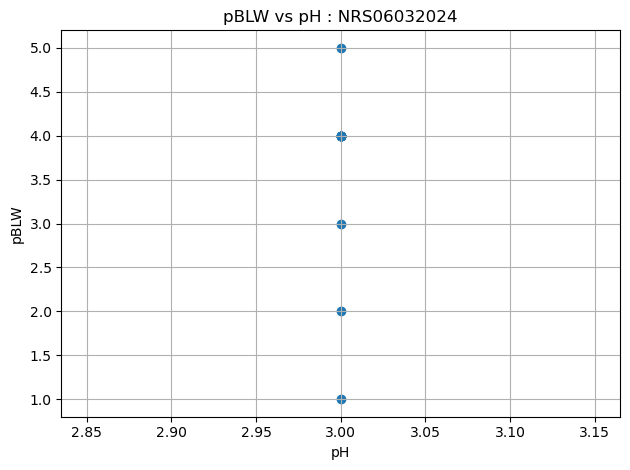

In [ ]:
# Test 1: data import and param extraction
root = "C:/Users/robert/Desktop/capstone/capstone_SiC_gratings/data/AFM/NRS06032024"
afm_data = load_all_AFM(root, sample_name = "NRS06032024")
x, y = get_param_pairs_AFM(afm_data, "pH", "pBLW", plot=True)

In [ ]:
# Test 2: Measuring TLW and BLW